# Unit 4 — Notebook 1: Containerizing Your Portfolio Model with Docker

**What you will learn:**
1. What Docker is and why it solves the "works on my machine" problem
2. How a Dockerfile, image, container, and registry relate to each other
3. How to stage **your own model artifact** into a build context and write a Dockerfile around it
4. How to build and run Docker containers and inspect them with CLI commands

**The model:** this notebook containerizes the portfolio model you exported from AIAT 114 or AIAT 122 — the same artifact Units 1 and 2 served over HTTP. See [`../../PORTFOLIO_MODEL.md`](../../PORTFOLIO_MODEL.md). If you have not exported one yet, the notebook builds and containerizes the named fallback `wdbc-baseline` and says so in its output.

**How to use this notebook:** Run cells top to bottom. `%%writefile` cells create real files on disk. `subprocess` cells show you the commands — they run for real when Docker is installed *and its daemon is running*; in every other case (no CLI, stopped daemon) they print the command plus the typical output, clearly labeled, so you can follow along on any machine.

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 1, lesson 01 "00. Python Libraries for AI" — you installed a specific stack of libraries to make AI code run at all; a Dockerfile writes that install list down so any machine can rebuild the same environment, which is what ends "works on my machine".

**Used later in:** Course 12 (AIAT 126) — Unit 5, lesson 01 "Project Documentation and Presentation", whose deliverable checklist asks for live-demo setup instructions — a container image is the least fragile way to supply them.


---
## Section 1 — The "Works on My Machine" Problem

You train a model on your laptop (Python 3.10, scikit-learn 1.3, numpy 1.24). You hand it to a colleague running Python 3.8 on Ubuntu, or you deploy it to a server with a different OS. It breaks.

**Docker solves this** by packaging your code, model, and every dependency together into a single artifact — an *image* — that runs identically anywhere Docker is installed.

The diagram below shows the transformation:


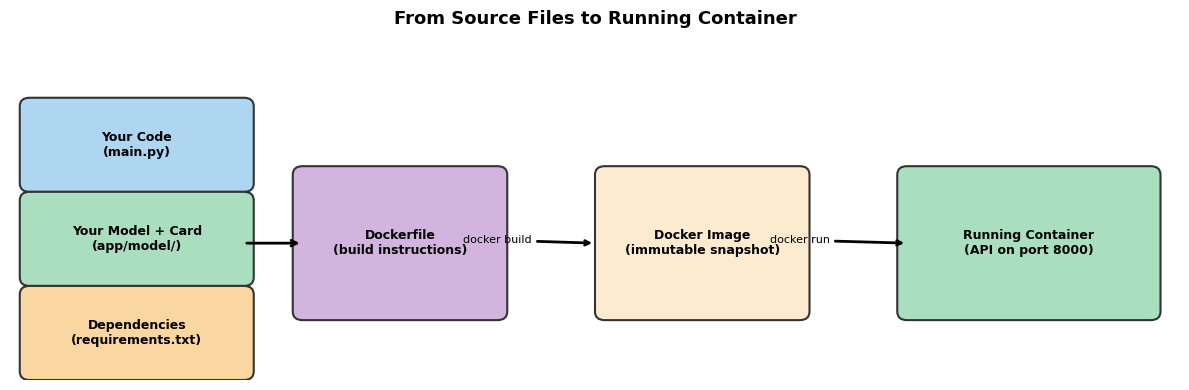

In [1]:
# WHAT: draw the Docker pipeline diagram: source files -> Dockerfile -> image -> container.
# WHY: these four boxes are the whole lesson — every cell below builds one of
# them; keep this picture in mind as the map.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis('off')

# Box helper
def box(ax, x, y, w, h, label, color):
    rect = mpatches.FancyBboxPatch((x, y), w, h,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=9, fontweight='bold', wrap=True)

# The three things we ship: code, YOUR staged model artifact, and pinned dependencies.
# Left: inputs
box(ax, 0.2, 2.3, 2.2, 0.9, 'Your Code\n(main.py)', '#AED6F1')
box(ax, 0.2, 1.2, 2.2, 0.9, 'Your Model + Card\n(app/model/)', '#A9DFBF')
box(ax, 0.2, 0.1, 2.2, 0.9, 'Dependencies\n(requirements.txt)', '#FAD7A0')

# Arrow → Dockerfile
ax.annotate('', xy=(3.0, 1.6), xytext=(2.4, 1.6),
            arrowprops=dict(arrowstyle='->', lw=2))

# Dockerfile box
box(ax, 3.0, 0.8, 2.0, 1.6, 'Dockerfile\n(build instructions)', '#D2B4DE')

# Arrow → Image
ax.annotate('docker build', xy=(6.0, 1.6), xytext=(5.0, 1.6),
            arrowprops=dict(arrowstyle='->', lw=2), fontsize=8, ha='center')

# Image box
box(ax, 6.1, 0.8, 2.0, 1.6, 'Docker Image\n(immutable snapshot)', '#FDEBD0')

# Arrow → Container
ax.annotate('docker run', xy=(9.2, 1.6), xytext=(8.1, 1.6),
            arrowprops=dict(arrowstyle='->', lw=2), fontsize=8, ha='center')

# Container box
box(ax, 9.2, 0.8, 2.5, 1.6, 'Running Container\n(API on port 8000)', '#A9DFBF')

ax.set_title('From Source Files to Running Container', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## Section 2 — Docker Concepts: Image, Container, Registry

| Concept | Analogy | Description |
|---|---|---|
| **Dockerfile** | Recipe | Text file with instructions for building an image |
| **Image** | Cake (baked) | Read-only snapshot produced by `docker build` |
| **Container** | Serving a slice | A running instance of an image |
| **Registry** | Cookbook library | Remote store for images (Docker Hub, ECR, GCR) |

One image can spawn many containers simultaneously — this is how you scale horizontally.


---
## Section 3 — Stage the Model and Write the App Files

Docker builds from a **build context**: one folder, and nothing outside it. Your portfolio model lives in `~/ai-diploma-portfolio/`, which is outside `app/` — so the first real containerization step is *staging*: copying the artifact and its card into the context.

That copy is not a notebook convenience. In a production pipeline the same step pulls the artifact from a model registry (`mlflow artifacts download`, `aws s3 cp`, a GitHub release asset). The image must contain everything it needs, because at runtime there is no home directory, no notebook, and no network guarantee.

We then write the serving app and the pinned requirements with `%%writefile`, so they land on disk exactly as they would in a real project.

In [2]:
# WHAT: create the build context folder that Docker will copy into the image.
# WHY: everything the container needs - code, model, requirements, Dockerfile -
# has to live under this one directory. Nothing outside it can be COPYed.
import os
os.makedirs('app/model', exist_ok=True)
print('Created app/ and app/model/')


Created app/ and app/model/


In [3]:
%%writefile app/stage_model.py
# WHAT: copy YOUR portfolio artifact and its card into app/model/.
# WHY: Docker can only copy files that live inside the build context (the app/
# folder). Your model lives in your home directory, so "staging" it into the
# context is a real build step - in a production pipeline this same step is an
# `aws s3 cp` or `mlflow artifacts download` from a model registry.
"""Stage the AIAT 125 portfolio model into the Docker build context."""
import json
import os
import shutil
from pathlib import Path

PORTFOLIO = Path(os.environ.get("AI_DIPLOMA_PORTFOLIO",
                                str(Path.home() / "ai-diploma-portfolio")))
DEST = Path(__file__).parent / "model"


def stage(portfolio: Path = PORTFOLIO, dest: Path = DEST) -> dict:
    """Copy model_card.json + the artifact it names into dest/. Returns the card."""
    card_path = portfolio / "model_card.json"
    if not card_path.exists():
        raise FileNotFoundError(
            f"No model_card.json in {portfolio}. Export a model first - see "
            "Course 11/PORTFOLIO_MODEL.md - or run any Unit 1 notebook to build "
            "the named fallback."
        )
    card = json.loads(card_path.read_text())
    dest.mkdir(parents=True, exist_ok=True)
    shutil.copy2(card_path, dest / "model_card.json")
    shutil.copy2(portfolio / card["artifact"], dest / card["artifact"])
    return card


if __name__ == "__main__":
    staged = stage()
    print(f"Staged '{staged['name']}' ({staged['artifact']}) into {DEST}")


Overwriting app/stage_model.py


In [4]:
# WHAT: load the portfolio model (building the named fallback if needed), then
# run the staging script exactly as its docstring says: python stage_model.py.
# WHY: the image is only as good as what we put in the build context. Running the
# real script here means the notebook and the container ship the SAME bytes.
import json
import subprocess
import sys
from pathlib import Path

for _d in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (_d / "portfolio_model.py").exists():
        COURSE11 = _d
        break
else:
    raise FileNotFoundError("Could not find portfolio_model.py - run this notebook from inside Course 11.")

if str(COURSE11) not in sys.path:
    sys.path.insert(0, str(COURSE11))

import portfolio_model as pf

model, card = pf.load_portfolio_model()

# Run the staging script as a script - the same command you would put in a Makefile.
result = subprocess.run([sys.executable, "stage_model.py"], cwd="app",
                        capture_output=True, text=True, timeout=120)
print()
print(result.stdout.strip() or result.stderr.strip())
result.check_returncode()

print("\nBuild context now contains:")
for f in sorted(Path("app/model").iterdir()):
    print(f"  app/model/{f.name}  ({f.stat().st_size / 1024:.1f} KB)")


No portfolio model found at /Users/abdullah/ai-diploma-portfolio
-> Building the NAMED FALLBACK 'wdbc-baseline' so this lesson can run.


FALLBACK MODEL 'wdbc-baseline' — this is NOT your model.
  directory   : /Users/abdullah/ai-diploma-portfolio
  artifact    : model.joblib  (sklearn)
  task        : classification  ->  2 classes ['malignant', 'benign']
  features    : 30 (first three: ['mean radius', 'mean texture', 'mean perimeter'])
  accuracy    : 0.9825 on held-out 20% (random_state=42, stratified)
  Export your own model from AIAT 114 or AIAT 122 and re-run: see Course 11/PORTFOLIO_MODEL.md

Staged 'wdbc-baseline' (model.joblib) into /Users/abdullah/Downloads/AI Diploma/Course 11/unit4-containers-orchestration/examples/app/model

Build context now contains:
  app/model/model.joblib  (2.2 KB)
  app/model/model_card.json  (10.2 KB)


In [5]:
%%writefile app/main.py
# WHAT: the inference server that runs INSIDE the container.
# WHY: note where the artifact comes from. Unit 1 and Unit 2 read the portfolio
# directory in your home folder; a container has no home folder to read. The
# model is baked in at "model/", relative to WORKDIR /app - the image IS the
# artifact store, which is exactly what makes it reproducible.
"""FastAPI inference server for the staged portfolio model."""
import json
import os
import re
from pathlib import Path

import numpy as np
from fastapi import FastAPI
from pydantic import BaseModel, Field, create_model

MODEL_DIR = Path(os.environ.get("MODEL_DIR", "model"))
CARD = json.loads((MODEL_DIR / "model_card.json").read_text())
ARTIFACT = MODEL_DIR / CARD["artifact"]

if CARD["framework"] == "sklearn":
    import joblib
    _model = joblib.load(ARTIFACT)

    def probabilities(rows):
        return np.asarray(_model.predict_proba(rows))

elif CARD["framework"] == "onnx":
    import onnxruntime as ort
    _session = ort.InferenceSession(str(ARTIFACT), providers=["CPUExecutionProvider"])
    _input = _session.get_inputs()[0].name

    def probabilities(rows):
        logits = np.asarray(_session.run(None, {_input: np.asarray(rows, dtype=np.float32)})[0])
        exp = np.exp(logits - logits.max(axis=1, keepdims=True))
        return exp / exp.sum(axis=1, keepdims=True)

else:
    raise RuntimeError(f"This image serves 'sklearn' or 'onnx' artifacts, not {CARD['framework']!r}.")


def api_field(name):
    slug = re.sub(r"\W+", "_", str(name).strip().lower()).strip("_")
    return f"f_{slug}" if not slug or slug[0].isdigit() else slug

FIELD_ORDER = [api_field(n) for n in CARD["feature_names"]]

PredictRequest = create_model(
    "PredictRequest",
    **{field: (float, Field(..., description=f"training column: {original}"))
       for field, original in zip(FIELD_ORDER, CARD["feature_names"])},
)


class PredictResponse(BaseModel):
    prediction: str
    class_id: int
    confidence: float


app = FastAPI(title=f"{CARD['name']} API", version="1.0")


@app.get("/health")
def health():
    return {"status": "ok", "model": CARD["name"], "source": CARD["source_course"]}


@app.post("/predict", response_model=PredictResponse)
def predict(req: PredictRequest):
    row = [getattr(req, field) for field in FIELD_ORDER]
    proba = probabilities([row])[0]
    idx = int(np.argmax(proba))
    return PredictResponse(prediction=CARD["class_names"][idx],
                           class_id=idx,
                           confidence=round(float(proba[idx]), 4))

# Run locally: uvicorn main:app --host 0.0.0.0 --port 8000


Overwriting app/main.py


In [6]:
%%writefile app/requirements.txt
# WHAT: pin every dependency to an exact version in requirements.txt.
# WHY: '==' is what makes the image reproducible - the same build next year
# installs the same versions, avoiding 'works on my machine' drift.
# If your card says framework "onnx", swap scikit-learn+joblib for onnxruntime.
fastapi==0.110.0
uvicorn==0.29.0
scikit-learn==1.4.2
joblib==1.4.0
numpy==1.26.4
pydantic==2.6.4


Overwriting app/requirements.txt


In [7]:
%%writefile app/.dockerignore
# WHAT: tell Docker which files in the context NOT to copy into the image.
# WHY: __pycache__ holds bytecode compiled for the Python on YOUR machine; copied
# into an image built on a different Python it is dead weight at best. The same
# rule keeps secrets, virtualenvs and notebooks out of production images.
__pycache__/
*.pyc
.ipynb_checkpoints/
.env


Overwriting app/.dockerignore


Check that the files were created — this is the complete build context Docker will copy:

In [8]:
# WHAT: print the app/ directory tree, skipping whatever .dockerignore excludes.
# WHY: this is the complete build context Docker will copy - check that code,
# staged model, requirements and the Dockerfile are all present, and nothing else.
import os

for root, dirs, files in os.walk('app'):
    dirs[:] = [d for d in dirs if d not in {'__pycache__', '.ipynb_checkpoints'}]
    level = root.replace('app', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in sorted(files):
        if not f.endswith('.pyc'):
            print(f'{indent}  {f}')


app/
  .dockerignore
  Dockerfile
  Dockerfile.multistage
  main.py
  requirements.txt
  stage_model.py
  model/
    model.joblib
    model_card.json


### Prove the app runs outside the notebook

The file we are about to put in an image has to work with no notebook, no portfolio directory, and `app/` as its working directory. Test that now — a container that fails on startup is a much slower way to learn the same thing.

In [9]:
# WHAT: run app/main.py exactly as the container will - from inside app/, with
# no portfolio directory in sight - and call /predict through TestClient.
# WHY: "it worked in the notebook" is not evidence. A subprocess with cwd=app/
# proves the file we are about to COPY into the image loads model/ correctly.
import subprocess
import sys

probe = f"""
import json, sys
sys.path.insert(0, ".")
from fastapi.testclient import TestClient
import main
client = TestClient(main.app)
card = main.CARD
payload = dict(zip(main.FIELD_ORDER, card["sample_input"]))
print("health :", client.get("/health").json())
print("predict:", client.post("/predict", json=payload).json())
print("fields :", len(main.FIELD_ORDER))
"""

result = subprocess.run([sys.executable, "-c", probe], cwd="app",
                        capture_output=True, text=True, timeout=180)
print(result.stdout.strip() or "(no output)")
if result.returncode != 0:
    print("STDERR:", result.stderr.strip().splitlines()[-1])
    raise RuntimeError("app/main.py failed outside the notebook - fix it before building the image.")
print("\napp/main.py runs standalone -> safe to COPY into the image.")


health : {'status': 'ok', 'model': 'wdbc-baseline', 'source': 'AIAT 125 fallback'}
predict: {'prediction': 'benign', 'class_id': 1, 'confidence': 0.9991}
fields : 30

app/main.py runs standalone -> safe to COPY into the image.


---
## Section 4 — Writing the Dockerfile

A Dockerfile is a list of instructions Docker executes top-to-bottom to produce an image. Each instruction creates a *layer* — Docker caches layers, so unchanged layers don't rebuild.


In [10]:
%%writefile app/Dockerfile
# WHAT: write the Dockerfile — the build recipe for the image.
# WHY: the ORDER of lines is deliberate: requirements are copied and installed
# before the code so Docker's layer cache skips reinstalling deps on code edits.
# Base image: official Python 3.10, slim variant (no unnecessary OS packages)
FROM python:3.10-slim

# Set the working directory inside the container
WORKDIR /app

# Copy requirements first — this layer is cached unless requirements change
COPY requirements.txt .

# Install Python dependencies (no cache saves image space)
RUN pip install --no-cache-dir -r requirements.txt

# Copy the rest of the app (model files, main.py)
COPY . .

# Expose the port the app listens on (documentation only — docker run -p maps it)
EXPOSE 8000

# Default command when the container starts
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]

Overwriting app/Dockerfile


### Why copy `requirements.txt` before the rest of the code?

Docker builds images layer by layer. If you copy everything at once and then run `pip install`, every code change (even a one-line fix) forces a full `pip install` — which can take minutes.

By copying `requirements.txt` first and running `pip install` as a separate step, Docker caches that layer. As long as `requirements.txt` doesn't change, `pip install` is skipped on the next build.

### Why `python:3.10-slim` instead of `python:3.10`?

The full `python:3.10` image is ~900 MB (includes compilers, documentation, build tools). The `slim` variant is ~130 MB — it has only what's needed to run Python. Smaller images pull faster, reduce attack surface, and cost less storage.


---
## Section 5 — Building the Image

`docker build -t portfolio-api:v1 app/` reads the Dockerfile in `app/`, executes each instruction, and tags the resulting image as `portfolio-api:v1`.


In [11]:
# Build the image — via a helper that is honest about ALL three real-world cases:
#   1. Docker installed AND daemon running  -> run the command, show real output
#   2. Docker CLI not installed             -> FileNotFoundError
#   3. CLI present but daemon stopped       -> command fails with "Cannot connect"
# Cases 2 and 3 both fall back to printing the command + the typical output, so
# the notebook never shows raw error walls or falsely claims success.
import subprocess

def run_docker(cmd, expected, timeout=120):
    """Run a docker command; print a labeled teaching fallback on any failure."""
    print("Command:", " ".join(cmd))
    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
        if r.returncode == 0:
            # Real success: show the genuine output
            print(r.stdout.strip() or "(command succeeded with no output)")
            return True
        # Command ran but failed (typically: daemon not running) — say why, briefly
        reason = r.stderr.strip().splitlines()[0] if r.stderr.strip() else f"exit code {r.returncode}"
        print(f"[Docker not available] {reason}")
    except FileNotFoundError:
        print("[Docker not available] The docker CLI is not installed on this machine.")
    except subprocess.TimeoutExpired:
        print(f"[Docker not available] Command timed out after {timeout}s.")
    # Teaching fallback: what you would see on a machine with Docker running
    print("Typical output with Docker running:")
    print(expected)
    return False

run_docker(
    ["docker", "build", "-t", "portfolio-api:v1", "app/"],
    expected=(
        "  Step 1/6 : FROM python:3.10-slim\n"
        "  Step 2/6 : WORKDIR /app\n"
        "  Step 3/6 : COPY requirements.txt .\n"
        "  Step 4/6 : RUN pip install --no-cache-dir -r requirements.txt\n"
        "  Step 5/6 : COPY . .\n"
        "  Step 6/6 : CMD [uvicorn main:app ...]\n"
        "  Successfully built a1b2c3d4e5f6\n"
        "  Successfully tagged portfolio-api:v1"
    ),
)


Command: docker build -t portfolio-api:v1 app/


(command succeeded with no output)


True

In [12]:
# List local images to confirm the build (uses the run_docker helper above)
run_docker(
    ["docker", "images", "portfolio-api"],
    expected=(
        "REPOSITORY   TAG   IMAGE ID       CREATED        SIZE\n"
        "portfolio-api     v1    a1b2c3d4e5f6   1 minute ago   215MB"
    ),
)


Command: docker images portfolio-api
IMAGE                   ID             DISK USAGE   CONTENT SIZE   EXTRA
portfolio-api:v1        87c064c9fe02        573MB          126MB        
portfolio-api:v1-slim   012bf7b1bc31        564MB          124MB


True

---
## Section 6 — Running, Inspecting, and Stopping Containers

Once you have an image, you start containers from it. You can run many containers from the same image simultaneously.


In [13]:
# Start a container from the image.
# docker run flags:
#   -d           : detached mode (runs in background)
#   -p 8000:8000 : map host port 8000 to container port 8000
#   --name       : give the container a friendly name
run_docker(
    ["docker", "run", "-d", "-p", "8000:8000", "--name", "portfolio-api", "portfolio-api:v1"],
    expected="9f3a2b1c0d4e5f6a7b8c9d0e1f2a3b4c5d6e7f8a9b0c1d2e3f4a5b6c7d8e9f0a  (the new container's ID)",
)


Command: docker run -d -p 8000:8000 --name portfolio-api portfolio-api:v1
017ce1b70573a4886775f22f7b012966f5e307c04dc7f8b038b958491ad6e4f7


True

In [14]:
# Inspect running containers — each row is one live container
run_docker(
    ["docker", "ps"],
    expected=(
        "CONTAINER ID  IMAGE       COMMAND       CREATED       STATUS       PORTS                  NAMES\n"
        "9f3a2b1c0d4e  portfolio-api:v1 'uvicorn ...' 5 seconds ago Up 4 seconds 0.0.0.0:8000->8000/tcp portfolio-api"
    ),
)


Command: docker ps


CONTAINER ID   IMAGE              COMMAND                  CREATED        STATUS                  PORTS                                         NAMES
017ce1b70573   portfolio-api:v1   "uvicorn main:app --…"   1 second ago   Up Less than a second   0.0.0.0:8000->8000/tcp, [::]:8000->8000/tcp   portfolio-api


True

In [15]:
# View logs from the running container — the app's stdout/stderr stream
# `docker logs` reads the app's stdout — first place to look when a container misbehaves.
run_docker(
    ["docker", "logs", "portfolio-api"],
    expected=(
        "INFO:     Started server process [1]\n"
        "INFO:     Waiting for application startup.\n"
        "INFO:     Application startup complete.\n"
        "INFO:     Uvicorn running on http://0.0.0.0:8000"
    ),
)

Command: docker logs portfolio-api


(command succeeded with no output)


True

In [16]:
# Stop, then remove the container. Both commands echo the container name on
# success — the helper reports honestly if they could not run.
run_docker(["docker", "stop", "portfolio-api"], expected="portfolio-api  (the stopped container's name)")
run_docker(["docker", "rm", "portfolio-api"], expected="portfolio-api  (the removed container's name)")


Command: docker stop portfolio-api


portfolio-api
Command: docker rm portfolio-api
portfolio-api


True

---
## Section 7 — Multi-Stage Builds (Optimization)

A multi-stage build uses one image to compile/build and a separate, smaller image for the final artifact. For Python ML services, this is useful when you need to compile C extensions (e.g., `numpy` from source) but want a lean runtime image.


In [17]:
%%writefile app/Dockerfile.multistage
# WHAT: write a multi-stage Dockerfile: build with the full image, run on slim.
# WHY: compilers and build tools are needed to INSTALL packages but not to RUN
# them — copying only the installed packages into slim shrinks the image.
# ── Stage 1: builder ────────────────────────────────────────────────────────
# Uses the full image so we have compilers for C extensions
FROM python:3.10 AS builder

WORKDIR /build

# Install dependencies into a local prefix (not system site-packages)
COPY requirements.txt .
RUN pip install --no-cache-dir --prefix=/install -r requirements.txt

# ── Stage 2: runtime ────────────────────────────────────────────────────────
# slim has no compilers — much smaller
FROM python:3.10-slim

WORKDIR /app

# Copy only the installed packages from the builder stage
COPY --from=builder /install /usr/local

# Copy application code and model
COPY . .

EXPOSE 8000
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]

Overwriting app/Dockerfile.multistage


In [18]:
# Build the multi-stage image and compare its size with the single-stage one
# Same app, two Dockerfiles: the size difference is pure build-stage baggage.
run_docker(
    ["docker", "build", "-f", "app/Dockerfile.multistage", "-t", "portfolio-api:v1-slim", "app/"],
    expected=(
        "Successfully built b2c3d4e5f6a7\n"
        "Successfully tagged portfolio-api:v1-slim\n"
        "\n"
        "docker images portfolio-api would then show:\n"
        "portfolio-api  v1        a1b2c3  ...  215MB   <- single stage\n"
        "portfolio-api  v1-slim   b2c3d4  ...  148MB   <- multi-stage"
    ),
    timeout=180,
)

Command: docker build -f app/Dockerfile.multistage -t portfolio-api:v1-slim app/


(command succeeded with no output)


True

---
## Summary

Docker gives you three concrete benefits for ML deployment:

1. **Reproducibility** — the exact same Python version, package versions, and OS libraries run in development, CI, and production.
2. **Isolation** — each container has its own filesystem and network, so models don't interfere with each other.
3. **Portability** — an image built on a MacBook runs unchanged on an AWS EC2 instance or a Kubernetes cluster.

The workflow is always the same: **stage the artifact** → write app files → write Dockerfile → `docker build` → `docker run`.

Notice what changed about the model between Unit 1 and here. The artifact never changed — the same file you exported from AIAT 114 or AIAT 122 has now been served three ways. What changed is *where the app looks for it*: your home directory in Units 1–2, a baked-in `model/` directory here. A container that reads its model from the host is not portable, and portability was the whole point.

**Next:** Notebook 02 covers Kubernetes — how to run many copies of this container, auto-scale them, and recover from crashes automatically.


---
## Self-Check Questions

Answer without scrolling, then verify by re-reading the relevant section.

1. **What is the difference between a Docker image and a container?**
   *(Hint: think about the cake analogy in Section 2.)*

2. **Why use `python:3.10-slim` instead of `python:3.10` as the base image?**
   *(Hint: Section 4 explains the size difference.)*

3. **What would happen if you copied all files first and then ran `pip install`, instead of copying `requirements.txt` first?**
   *(Hint: think about Docker layer caching.)*

4. **Why does `app/main.py` read `model/`, while the Unit 1 and Unit 2 apps read `~/ai-diploma-portfolio/`?**
   *(Hint: what exists inside a running container, and what does not?)*

5. **The staging step copies your artifact into the build context. What would break if you instead mounted your home directory into the container at run time?**


## 📚 References

1. Merkel, D. (2014). *Docker: Lightweight Linux Containers for Consistent Development and Deployment*. Linux Journal. <https://www.linuxjournal.com/content/docker-lightweight-linux-containers-consistent-development-and-deployment>
2. Boettiger, C. (2015). *An Introduction to Docker for Reproducible Research*. ACM SIGOPS Operating Systems Review 49(1). <https://arxiv.org/abs/1410.0846>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
